In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
tickers = [ "AAPL","MSFT","TSLA"]
data = yf.download(tickers, start = "2022-01-01",end = "2025-01-01",auto_adjust=True)

[*********************100%***********************]  3 of 3 completed


In [6]:
print(data.head())
print(data.shape)

Price            Close                                High              \
Ticker            AAPL        MSFT        TSLA        AAPL        MSFT   
Date                                                                     
2022-01-03  177.939774  322.462372  399.926666  178.790328  325.593074   
2022-01-04  175.681396  316.933136  383.196655  178.848946  322.895924   
2022-01-05  171.008270  304.766693  362.706665  176.140865  314.101006   
2022-01-06  168.153580  302.358398  354.899994  171.379785  307.001478   
2022-01-07  168.319794  302.512604  342.320007  170.245740  304.882297   

Price                          Low                                Open  \
Ticker            TSLA        AAPL        MSFT        TSLA        AAPL   
Date                                                                     
2022-01-03  400.356659  173.735945  317.674804  378.679993  173.853256   
2022-01-04  402.666656  175.114365  314.149204  374.350006  178.545881   
2022-01-05  390.113342  170.734533  3

In [7]:
close_price = data["Close"]
print (close_price.head())
print (close_price.describe())

Ticker            AAPL        MSFT        TSLA
Date                                          
2022-01-03  177.939774  322.462372  399.926666
2022-01-04  175.681396  316.933136  383.196655
2022-01-05  171.008270  304.766693  362.706665
2022-01-06  168.153580  302.358398  354.899994
2022-01-07  168.319794  302.512604  342.320007
Ticker        AAPL        MSFT        TSLA
count   753.000000  753.000000  753.000000
mean    175.865982  327.057399  237.078544
std      29.453652   70.771102   61.177708
min     122.933540  207.733978  108.099998
25%     153.263641  263.575439  189.979996
50%     171.030365  318.386597  233.190002
75%     189.415894  403.263580  267.480011
max     257.375610  460.325623  479.859985


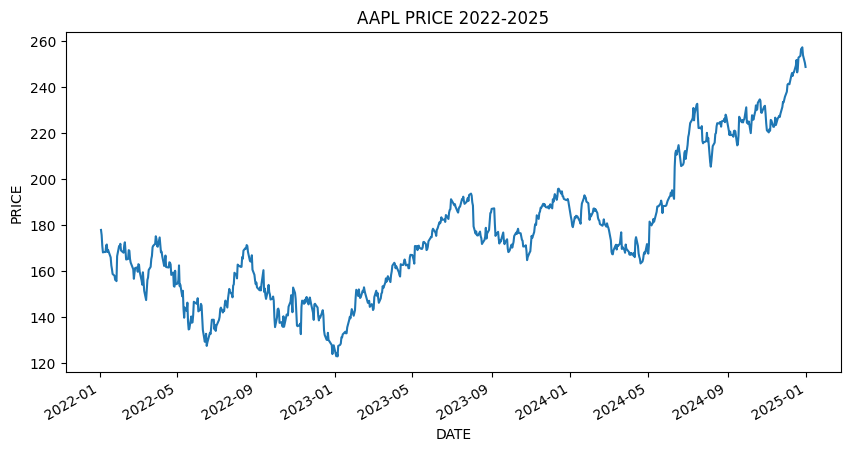

In [17]:
close_price["AAPL"].plot(figsize=(10,5),title="AAPL PRICE 2022-2025")
plt.xlabel("DATE")
plt.ylabel("PRICE")
plt.savefig('images/price_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

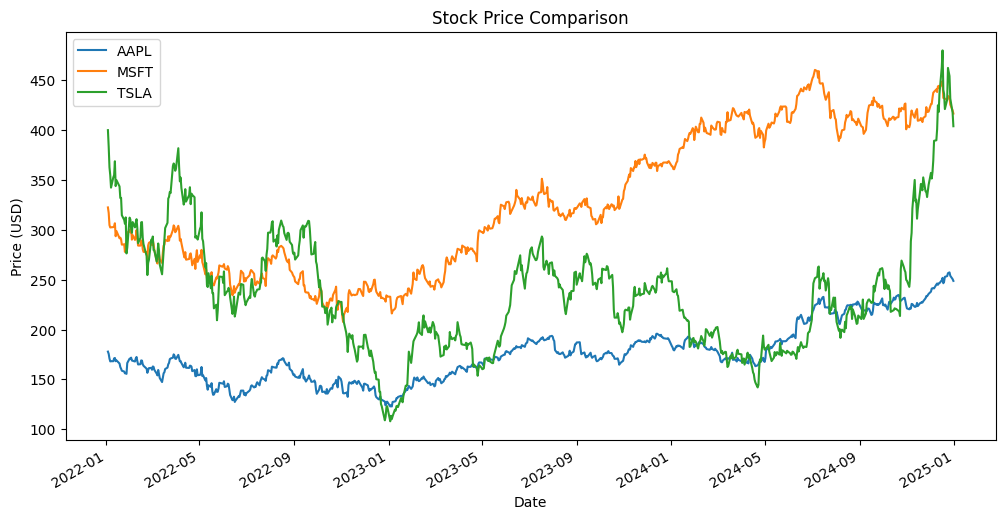

In [9]:
close_price.plot(figsize=(12,6), title="Stock Price Comparison")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend(tickers)
plt.savefig('images/price_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
daily_returns= close_price.pct_change()
print(daily_returns.head())
print(daily_returns.describe())

Ticker          AAPL      MSFT      TSLA
Date                                    
2022-01-03       NaN       NaN       NaN
2022-01-04 -0.012692 -0.017147 -0.041833
2022-01-05 -0.026600 -0.038388 -0.053471
2022-01-06 -0.016693 -0.007902 -0.021523
2022-01-07  0.000988  0.000510 -0.035447
Ticker        AAPL        MSFT        TSLA
count   752.000000  752.000000  752.000000
mean      0.000591    0.000491    0.000755
std       0.017067    0.017372    0.038618
min      -0.058680   -0.077156   -0.123346
25%      -0.008437   -0.008516   -0.020363
50%       0.001117    0.000789    0.000998
75%       0.009751    0.010602    0.020849
max       0.088974    0.082268    0.219190


In [11]:
volatility= daily_returns.std()
print (volatility)

Ticker
AAPL    0.017067
MSFT    0.017372
TSLA    0.038618
dtype: float64


In [12]:
annual_volatility= volatility*(252**0.5)
print(annual_volatility)

Ticker
AAPL    0.270935
MSFT    0.275766
TSLA    0.613038
dtype: float64


In [13]:
correlation_matrix = daily_returns.corr()
print(correlation_matrix)

Ticker      AAPL      MSFT      TSLA
Ticker                              
AAPL    1.000000  0.684811  0.499556
MSFT    0.684811  1.000000  0.419587
TSLA    0.499556  0.419587  1.000000


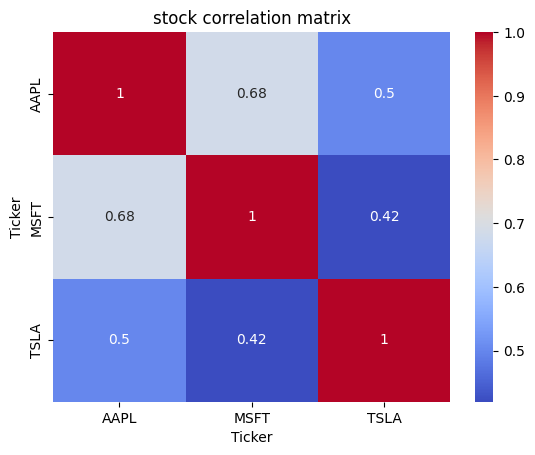

In [14]:
sns.heatmap(correlation_matrix, annot=True , cmap = "coolwarm")
plt.title("stock correlation matrix")
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
total_return = (close_price.iloc[-1]/close_price.iloc[0]-1)*100
print(total_return)

Ticker
AAPL    39.839579
MSFT    29.180471
TSLA     0.978512
dtype: float64


In [16]:
summary= pd.DataFrame({
    'Total return %' : total_return,
    ' annual volatility %' : annual_volatility*100
})
print (summary)

        Total return %   annual volatility %
Ticker                                      
AAPL         39.839579             27.093503
MSFT         29.180471             27.576594
TSLA          0.978512             61.303794
